# Análisis de solicitudes de préstamos

**Santiago Lara · LEAD University**  
Proyecto individual de Introducción a Ciencia de Datos.

Exploración, limpieza de datos y clasificación introductoria del estado de aprobación. Datos: [Home Loan Approval, Rushikesh Konapure](https://www.kaggle.com/datasets/rishikeshkonapure/home-loan-approval).

## Objetivo y datos

Cada fila representa una solicitud. `Loan_Status` registra aprobación (`Y`) o rechazo (`N`). El ejercicio busca explorar estas etiquetas y evaluar una regresión logística frente a una predicción de clase mayoritaria. No estima impago ni constituye un sistema para decidir créditos.

## Etapa 2: ETL básico
### A. Extracción de datos (Extract)

Se carga el archivo CSV descargado de Kaggle utilizando `pandas`, y se realiza una primera inspección: dimensiones, tipos de datos y primeras filas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Carga del dataset original (Extract)

from pathlib import Path
from IPython.display import display, Markdown
BASE = Path.cwd() if Path("loan_sanction_train.csv").exists() else Path.cwd() / "prestamos-python"
df = pd.read_csv(BASE / "loan_sanction_train.csv")
assert df["Loan_ID"].is_unique
assert df["Loan_Status"].notna().all()
assert set(df["Loan_Status"].unique()) == {"Y", "N"}

print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset tiene 614 filas y 13 columnas.


In [2]:
# Primeras filas del dataset
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Forma del dataset (filas, columnas)
df.shape

(614, 13)

In [4]:
# Información general: tipos de datos y valores no nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## Limpieza y análisis descriptivo

Se crea una copia para describir la muestra y exportarla. Esta copia imputada no se utiliza para entrenar ni evaluar el modelo. Más adelante, la preparación del modelo se ajusta exclusivamente con el conjunto de entrenamiento.

In [5]:
# Revisión de valores nulos por columna
nulos = df.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"valores_nulos": nulos, "porcentaje_%": porcentaje_nulos})
resumen_nulos[resumen_nulos["valores_nulos"] > 0]

,valores_nulos,porcentaje_%
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


In [6]:
# Separación de variables numéricas y categóricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object", "str"]).columns.tolist()

print("Variables numéricas:", columnas_numericas)
print("Variables categóricas:", columnas_categoricas)

Variables numéricas: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Variables categóricas: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


Los montos y plazos se completan con la mediana. Las categorías y el indicador binario de historial crediticio se completan con la moda. Se conservan las categorías legibles para el análisis descriptivo.

In [7]:
df_limpio = df.copy()

# Imputación de variables numéricas con la mediana
for col in ["LoanAmount", "Loan_Amount_Term"]:
    mediana = df_limpio[col].median()
    df_limpio[col] = df_limpio[col].fillna(mediana)
    print(f"'{col}': valores nulos rellenados con la mediana = {mediana}")

'LoanAmount': valores nulos rellenados con la mediana = 128.0
'Loan_Amount_Term': valores nulos rellenados con la mediana = 360.0


In [8]:
# Imputación de variables categóricas con la moda
for col in ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]:
    moda = df_limpio[col].mode()[0]
    df_limpio[col] = df_limpio[col].fillna(moda)
    print(f"'{col}': valores nulos rellenados con la moda = '{moda}'")

'Gender': valores nulos rellenados con la moda = 'Male'
'Married': valores nulos rellenados con la moda = 'Yes'
'Dependents': valores nulos rellenados con la moda = '0'
'Self_Employed': valores nulos rellenados con la moda = 'No'
'Credit_History': valores nulos rellenados con la moda = '1.0'


In [9]:
# Verificación: ya no deben quedar valores nulos
print("Valores nulos restantes por columna:")
print(df_limpio.isnull().sum().sum(), "valores nulos en total")

Valores nulos restantes por columna:
0 valores nulos en total


**Revisión de duplicados**

In [10]:
duplicados = df_limpio.duplicated().sum()
print(f"Cantidad de filas duplicadas: {duplicados}")

Cantidad de filas duplicadas: 0


`Loan_ID` se conserva como identificador de las solicitudes y se excluye de las variables predictoras.

In [11]:
loan_ids = df_limpio["Loan_ID"]
df_modelo = df_limpio.drop(columns=["Loan_ID"])
print("Columnas finales disponibles para el análisis y un futuro modelo:")
print(df_modelo.columns.tolist())

Columnas finales disponibles para el análisis y un futuro modelo:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


### C. Carga o salida final (Load)

Se guarda el dataset limpio (con las categorías en su forma original y legible, sin `Loan_ID`) como archivo CSV final: `home_loan_clean.csv`.

In [12]:
# Guardar el dataset limpio en el mismo directorio del notebook

df_final = df_modelo.copy()

df_final.to_csv(BASE / "home_loan_clean.csv", index=False)

print("Archivo 'home_loan_clean.csv' generado correctamente.")
print(f"Dimensiones finales: {df_final.shape[0]} filas x {df_final.shape[1]} columnas")

df_final.head()

Archivo 'home_loan_clean.csv' generado correctamente.
Dimensiones finales: 614 filas x 12 columnas


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Etapa 3: Análisis exploratorio de datos (EDA)
### Análisis general

In [13]:
print(f"Cantidad de registros: {df_modelo.shape[0]}")
print(f"Cantidad de variables: {df_modelo.shape[1]}")
print(f"\nTipos de variables:\n{df_modelo.dtypes}")

Cantidad de registros: 614
Cantidad de variables: 12

Tipos de variables:
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [14]:
# Estadísticas descriptivas de variables numéricas
df_modelo.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


### Análisis de la variable objetivo: `Loan_Status`

In [15]:
conteo_status = df_modelo["Loan_Status"].value_counts()
porcentaje_status = df_modelo["Loan_Status"].value_counts(normalize=True).mul(100).round(1)
print("Conteo de solicitudes por estado:")
print(conteo_status)
print("\nPorcentaje:")
print(porcentaje_status)

Conteo de solicitudes por estado:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Porcentaje:
Loan_Status
Y    68.7
N    31.3
Name: proportion, dtype: float64


### Análisis de posibles variables predictoras

In [16]:
# Relación entre Credit_History y Loan_Status
tabla_credito = pd.crosstab(df_modelo["Credit_History"], df_modelo["Loan_Status"], normalize="index").mul(100).round(1)
print("Porcentaje de aprobación según historial crediticio:")
tabla_credito

Porcentaje de aprobación según historial crediticio:


Loan_Status,N,Y
Credit_History,,
0.0,92.1,7.9
1.0,21.0,79.0


In [17]:
# Ingreso promedio del solicitante según el resultado del préstamo
df_modelo.groupby("Loan_Status")["ApplicantIncome"].describe()[["mean", "50%", "std"]]

,mean,50%,std
Loan_Status,,,
N,5446.078125,3833.5,6819.558528
Y,5384.068720,3812.5,5765.441615


In [18]:
# Relación entre zona de la propiedad y aprobación
tabla_zona = pd.crosstab(df_modelo["Property_Area"], df_modelo["Loan_Status"], normalize="index").mul(100).round(1)
print("Porcentaje de aprobación según zona de propiedad:")
tabla_zona

Porcentaje de aprobación según zona de propiedad:


Loan_Status,N,Y
Property_Area,,
Rural,38.5,61.5
Semiurban,23.2,76.8
Urban,34.2,65.8


In [19]:
# Relación entre educación y aprobación
tabla_educacion = pd.crosstab(df_modelo["Education"], df_modelo["Loan_Status"], normalize="index").mul(100).round(1)
print("Porcentaje de aprobación según nivel educativo:")
tabla_educacion

Porcentaje de aprobación según nivel educativo:


Loan_Status,N,Y
Education,,
Graduate,29.2,70.8
Not Graduate,38.8,61.2


## Visualizaciones

Distribución de las solicitudes, ingresos, montos e indicadores asociados con las etiquetas históricas. Las asociaciones observadas no demuestran causalidad.

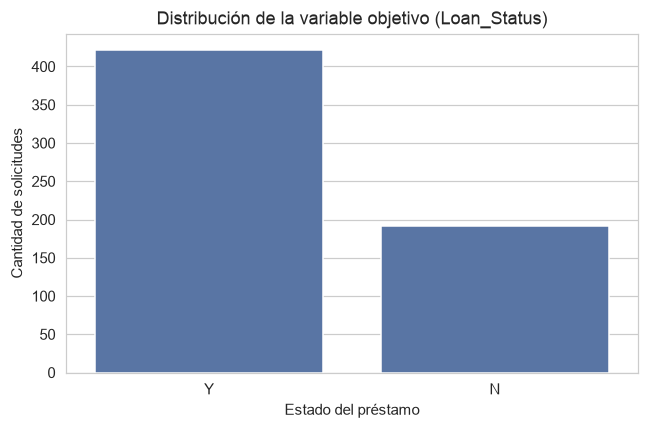

In [20]:
# Visualización 1: Distribución de Loan_Status

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df_modelo,
    x="Loan_Status",
    color="#4C72B0",
    ax=ax
)

ax.set_title("Distribución de la variable objetivo (Loan_Status)")
ax.set_xlabel("Estado del préstamo")
ax.set_ylabel("Cantidad de solicitudes")

plt.tight_layout()
plt.show()

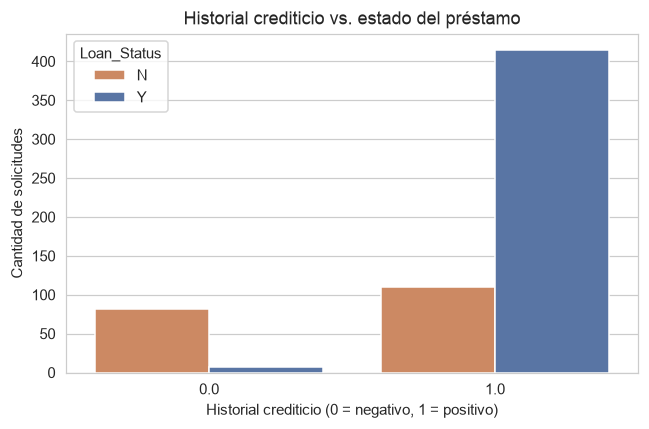

In [21]:
# Visualización 2: Credit_History vs Loan_Status

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df_modelo,
    x="Credit_History",
    hue="Loan_Status",
    hue_order=["N", "Y"],
    palette={"N":"#DD8452", "Y":"#4C72B0"},
    ax=ax
)

ax.set_title("Historial crediticio vs. estado del préstamo")
ax.set_xlabel("Historial crediticio (0 = negativo, 1 = positivo)")
ax.set_ylabel("Cantidad de solicitudes")

plt.tight_layout()
plt.show()

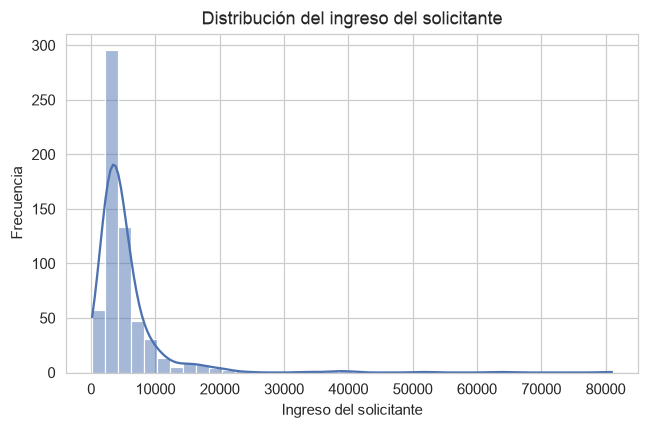

In [22]:
# Visualización 3: Histograma de ApplicantIncome

fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    df_modelo["ApplicantIncome"],
    bins=40,
    kde=True,
    color="#4C72B0",
    ax=ax
)

ax.set_title("Distribución del ingreso del solicitante")
ax.set_xlabel("Ingreso del solicitante")
ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

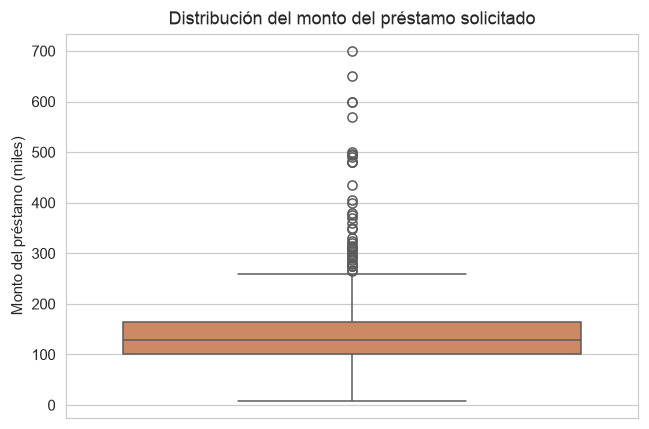

In [23]:
# Visualización 4: Boxplot de LoanAmount

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=df_modelo,
    y="LoanAmount",
    color="#DD8452",
    ax=ax
)

ax.set_title("Distribución del monto del préstamo solicitado")
ax.set_ylabel("Monto del préstamo (miles)")

plt.tight_layout()
plt.show()

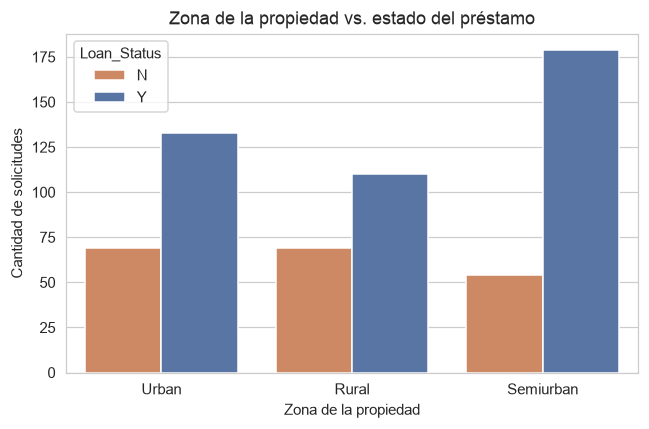

In [24]:
# Visualización 5: Property_Area vs Loan_Status

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df_modelo,
    x="Property_Area",
    hue="Loan_Status",
    hue_order=["N", "Y"],
    palette={"N":"#DD8452", "Y":"#4C72B0"},
    ax=ax
)

ax.set_title("Zona de la propiedad vs. estado del préstamo")
ax.set_xlabel("Zona de la propiedad")
ax.set_ylabel("Cantidad de solicitudes")

plt.tight_layout()
plt.show()

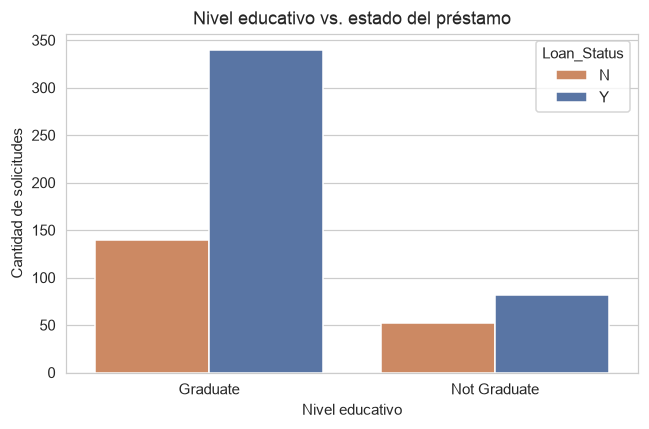

In [25]:
# Visualización 6: Education vs Loan_Status

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df_modelo,
    x="Education",
    hue="Loan_Status",
    hue_order=["N", "Y"],
    palette={"N":"#DD8452", "Y":"#4C72B0"},
    ax=ax
)

ax.set_title("Nivel educativo vs. estado del préstamo")
ax.set_xlabel("Nivel educativo")
ax.set_ylabel("Cantidad de solicitudes")

plt.tight_layout()
plt.show()

## Modelo: separación antes de preparar los datos

Se reserva el 20% de las solicitudes como prueba con estratificación y semilla fija. La imputación, la codificación de categorías y la normalización se aprenden únicamente del 80% de entrenamiento. El análisis es exploratorio: para una evaluación final se necesitaría una muestra externa no examinada durante el desarrollo.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

X = df.drop(columns=['Loan_ID','Loan_Status'])
y = df['Loan_Status'].map({'N':0,'Y':1})
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
numericas = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
categoricas = ['Gender','Married','Dependents','Education','Self_Employed','Credit_History','Property_Area']
preparacion = ColumnTransformer([
    ('numericas', Pipeline([('imputacion',SimpleImputer(strategy='median')),('escala',StandardScaler())]), numericas),
    ('categoricas', Pipeline([('imputacion',SimpleImputer(strategy='most_frequent')),('codificacion',OneHotEncoder(handle_unknown='ignore'))]), categoricas)
])
modelo = Pipeline([('preparacion',preparacion),('clasificador',LogisticRegression(max_iter=5000,random_state=42))])
modelo.fit(X_train,y_train)
y_pred = modelo.predict(X_test)
base = DummyClassifier(strategy='most_frequent').fit(X_train,y_train)
y_base = base.predict(X_test)
print(f'Entrenamiento: {len(X_train)} solicitudes. Prueba: {len(X_test)} solicitudes.')

Entrenamiento: 491 solicitudes. Prueba: 123 solicitudes.


## Evaluación

La exactitud se compara con una línea base. La exactitud balanceada otorga el mismo peso a ambas clases. La matriz y el reporte muestran qué tipos de error comete el modelo.

,Exactitud,Exactitud balanceada
Modelo,,
Clase mayoritaria,69.1%,50.0%
Regresión logística,86.2%,78.4%


              precision    recall  f1-score   support

 No aprobado       0.96      0.58      0.72        38
    Aprobado       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



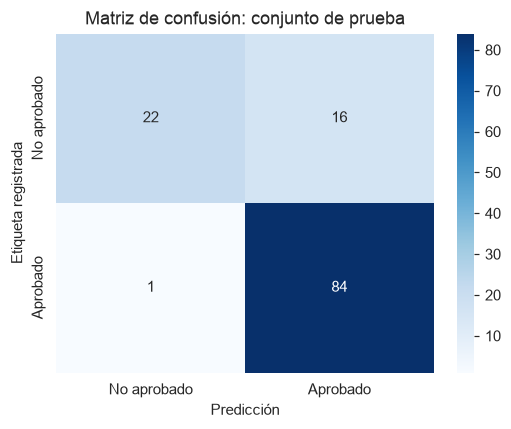

In [27]:
evaluacion = pd.DataFrame([
    {'Modelo':'Clase mayoritaria','Exactitud':accuracy_score(y_test,y_base),'Exactitud balanceada':balanced_accuracy_score(y_test,y_base)},
    {'Modelo':'Regresión logística','Exactitud':accuracy_score(y_test,y_pred),'Exactitud balanceada':balanced_accuracy_score(y_test,y_pred)}
]).set_index('Modelo')
display(evaluacion.map(lambda valor: f'{valor:.1%}'))
print(classification_report(y_test,y_pred,labels=[0,1],target_names=['No aprobado','Aprobado'],zero_division=0))
matriz = confusion_matrix(y_test,y_pred,labels=[0,1])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(matriz,annot=True,fmt='d',cmap='Blues',xticklabels=['No aprobado','Aprobado'],yticklabels=['No aprobado','Aprobado'],ax=ax)
ax.set(xlabel='Predicción',ylabel='Etiqueta registrada',title='Matriz de confusión: conjunto de prueba')
plt.tight_layout()
plt.show()

## Conclusiones

In [28]:
display(Markdown(f"""
La regresión logística obtiene **{accuracy_score(y_test,y_pred):.1%} de exactitud** en las {len(y_test)} solicitudes de prueba, frente a **{accuracy_score(y_test,y_base):.1%}** de la clase mayoritaria. Su exactitud balanceada es **{balanced_accuracy_score(y_test,y_pred):.1%}**.

Estos resultados corresponden a una única separación de una muestra pequeña. El modelo aprende aprobaciones históricas y puede reproducir sus sesgos; no demuestra solvencia ni probabilidad de impago. Una aplicación real requeriría datos representativos, revisión de variables y equidad, y validación externa.
"""))


La regresión logística obtiene **86.2% de exactitud** en las 123 solicitudes de prueba, frente a **69.1%** de la clase mayoritaria. Su exactitud balanceada es **78.4%**.

Estos resultados corresponden a una única separación de una muestra pequeña. El modelo aprende aprobaciones históricas y puede reproducir sus sesgos; no demuestra solvencia ni probabilidad de impago. Una aplicación real requeriría datos representativos, revisión de variables y equidad, y validación externa.
